In [5]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import zero_one_loss, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Task 1a: Load the table and familiarize with contents
# Load the grambank dataset
df = pd.read_csv('grambank.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Number of languages: {df.shape[0]}")
print(f"Number of features + macroarea column: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'hw9/grambank.csv'

In [ ]:
# Check column names
print(f"\nColumn names (first 10): {df.columns[:10].tolist()}")
print(f"Last column (macroarea): {df.columns[-1]}")

# Check for null values
print(f"\nNull values per column (first 10 features):")
print(df.iloc[:, :10].isnull().sum())


Column names (first 10): ['Language', 'GB020', 'GB021', 'GB022', 'GB023', 'GB024', 'GB025', 'GB026', 'GB027', 'GB028']
Last column (macroarea): Macroarea

Null values per column (first 10 features):
Language      0
GB020       266
GB021       243
GB022       257
GB023       259
GB024       264
GB025       205
GB026       692
GB027       685
GB028       108
dtype: int64


In [ ]:
# Check unique macroareas
print(f"\nUnique macroareas: {df.iloc[:, -1].unique()}")
print(f"Number of macroareas: {df.iloc[:, -1].nunique()}")

# Check data types
print(f"\nData types (first 10 features):")
print(df.dtypes[:10])


Unique macroareas: ['Papunesia' 'Eurasia' 'South America' 'Africa' 'North America'
 'Australia']
Number of macroareas: 6

Data types (first 10 features):
Language    object
GB020       object
GB021       object
GB022       object
GB023       object
GB024       object
GB025       object
GB026       object
GB027       object
GB028       object
dtype: object


In [ ]:
# Task 1b: Generate binarised version using get_dummies
# Separate features from macroarea column
features_df = df.iloc[:, :-1]  # All columns except the last one
macroarea_column = df.iloc[:, -1]  # Last column (macroarea)

# Apply get_dummies to the features (using default parameters)
# This will create separate columns for presence/absence of each feature
# and missing values will be indicated by zeros in both columns
features_binarized = pd.get_dummies(features_df)

print(f"Original features shape: {features_df.shape}")
print(f"Binarized features shape: {features_binarized.shape}")
print(f"Sample of binarized column names: {features_binarized.columns[:10].tolist()}")

Original features shape: (2463, 196)
Binarized features shape: (2463, 2861)
Sample of binarized column names: ["Language_'Are'are", "Language_A'ou", 'Language_Abadi', 'Language_Abau', 'Language_Abenlen Ayta', 'Language_Abipon', 'Language_Abkhaz', "Language_Abu' Arapesh", 'Language_Abui', 'Language_Abun']


In [ ]:
# Task 1c: Prepare feature matrix X and label vector y
# Convert binarized features to numpy array and cast to integers
X = features_binarized.values.astype(int)
print(f"Feature matrix X shape: {X.shape}")
print(f"Feature matrix X dtype: {X.dtype}")

# Convert macroarea labels to array of strings, then encode to integers
y_strings = macroarea_column.values.astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_strings)

print(f"Label vector y shape: {y.shape}")
print(f"Label vector y dtype: {y.dtype}")
print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Feature matrix X shape: (2463, 2861)
Feature matrix X dtype: int64
Label vector y shape: (2463,)
Label vector y dtype: int64
Label mapping: {'Africa': 0, 'Australia': 1, 'Eurasia': 2, 'North America': 3, 'Papunesia': 4, 'South America': 5}


In [ ]:
# Task 1d: Prepare train/test splits
# Split into 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# Check class distribution in train and test sets
print(f"\nClass distribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for class_id, count in zip(unique_train, counts_train):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"  {class_name}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nClass distribution in test set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for class_id, count in zip(unique_test, counts_test):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"  {class_name}: {count} ({count/len(y_test)*100:.1f}%)")

Training set shape: X_train=(1970, 2861), y_train=(1970,)
Test set shape: X_test=(493, 2861), y_test=(493,)

Class distribution in training set:
  Africa: 450 (22.8%)
  Australia: 115 (5.8%)
  Eurasia: 450 (22.8%)
  North America: 194 (9.8%)
  Papunesia: 582 (29.5%)
  South America: 179 (9.1%)

Class distribution in test set:
  Africa: 112 (22.7%)
  Australia: 28 (5.7%)
  Eurasia: 113 (22.9%)
  North America: 49 (9.9%)
  Papunesia: 146 (29.6%)
  South America: 45 (9.1%)


In [ ]:
# Task 2a: Fit a decision tree classifier and make predictions

# Create and fit decision tree with default settings
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on test data
y_pred_dt = dt_classifier.predict(X_test)

print("Decision tree fitted successfully!")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of predictions: {len(y_pred_dt)}")

Decision tree fitted successfully!
Number of test samples: 493
Number of predictions: 493


In [ ]:
# Task 2b: Compute accuracy using zero_one_loss
# Use zero_one_loss to compute accuracy
# Note: zero_one_loss gives the fraction of misclassifications
# So accuracy = 1 - zero_one_loss
zero_one_error = zero_one_loss(y_test, y_pred_dt)
accuracy_dt = 1 - zero_one_error

print(f"Zero-one loss (error rate): {zero_one_error:.4f}")
print(f"Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

# Alternative way to verify accuracy
accuracy_verify = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy (verification): {accuracy_verify:.4f}")

# Show some example predictions vs actual
print(f"\nFirst 10 predictions vs actual:")
print("Predicted | Actual    | Correct?")
print("-" * 35)
for i in range(min(10, len(y_test))):
    pred_name = label_encoder.inverse_transform([y_pred_dt[i]])[0]
    actual_name = label_encoder.inverse_transform([y_test[i]])[0]
    correct = "✓" if y_pred_dt[i] == y_test[i] else "✗"
    print(f"{pred_name:9} | {actual_name:9} | {correct}")

Zero-one loss (error rate): 0.3732
Accuracy: 0.6268 (62.68%)
Accuracy (verification): 0.6268

First 10 predictions vs actual:
Predicted | Actual    | Correct?
-----------------------------------
Eurasia   | South America | ✗
Papunesia | Eurasia   | ✗
South America | Papunesia | ✗
North America | North America | ✓
Papunesia | Papunesia | ✓
Papunesia | Papunesia | ✓
Australia | Africa    | ✗
North America | Papunesia | ✗
Africa    | Africa    | ✓
Papunesia | Papunesia | ✓


In [ ]:
# Task 2c: Analyze the decision tree structure and feature importance
# Number of leaves in the decision tree
n_leaves = dt_classifier.get_n_leaves()
print(f"Number of leaves in decision tree: {n_leaves}")

# Tree depth
tree_depth = dt_classifier.get_depth()
print(f"Tree depth: {tree_depth}")

# Feature importance
feature_importance = dt_classifier.feature_importances_
feature_names = features_binarized.columns

# Get indices of most important features
top_indices = np.argsort(feature_importance)[::-1][:10]  # Top 10 most important

print(f"\nTop 10 Most Important Features:")
print("Rank | Feature Name | Importance")
print("-" * 50)
for i, idx in enumerate(top_indices):
    print(f"{i+1:4} | {feature_names[idx]:30} | {feature_importance[idx]:.6f}")

# Focus on top 3 as requested
print(f"\nTop 3 Most Important Features (for Grambank lookup):")
for i in range(3):
    idx = top_indices[i]
    feature_name = feature_names[idx]
    importance = feature_importance[idx]
    print(f"{i+1}. {feature_name} (importance: {importance:.6f})")

Number of leaves in decision tree: 378
Tree depth: 20

Top 10 Most Important Features:
Rank | Feature Name | Importance
--------------------------------------------------
   1 | GB042_present                  | 0.075250
   2 | GB117_present                  | 0.052848
   3 | GB044_absent                   | 0.042597
   4 | GB025_Dem-N                    | 0.030735
   5 | GB328_present                  | 0.029800
   6 | GB057_present                  | 0.021786
   7 | GB326_absent                   | 0.017389
   8 | GB167_present                  | 0.017077
   9 | GB079_present                  | 0.016451
  10 | GB431_present                  | 0.014037

Top 3 Most Important Features (for Grambank lookup):
1. GB042_present (importance: 0.075250)
2. GB117_present (importance: 0.052848)
3. GB044_absent (importance: 0.042597)


In [ ]:
# Show feature importance distribution
print(f"\nFeature Importance Statistics:")
print(f"Mean importance: {np.mean(feature_importance):.6f}")
print(f"Max importance: {np.max(feature_importance):.6f}")
print(f"Min importance: {np.min(feature_importance):.6f}")
print(f"Features with zero importance: {np.sum(feature_importance == 0)}")

# Performance interpretation
print(f"\nPerformance Interpretation:")
if accuracy_dt > 0.8:
    print("✓ High accuracy - the decision tree performs well")
elif accuracy_dt > 0.6:
    print("~ Moderate accuracy - the decision tree shows some predictive power")
else:
    print("✗ Low accuracy - the decision tree struggles with this classification task")

print(f"\nWhat's going on:")
print(f"- The decision tree has {n_leaves} leaves and depth {tree_depth}")
print(f"- It uses {np.sum(feature_importance > 0)} out of {len(feature_importance)} features")
print(f"- The top feature accounts for {np.max(feature_importance)*100:.2f}% of decision importance")


Feature Importance Statistics:
Mean importance: 0.000350
Max importance: 0.075250
Min importance: 0.000000
Features with zero importance: 2605

Performance Interpretation:
~ Moderate accuracy - the decision tree shows some predictive power

What's going on:
- The decision tree has 378 leaves and depth 20
- It uses 256 out of 2861 features
- The top feature accounts for 7.53% of decision importance


In [ ]:
# Show confusion matrix for detailed analysis
print(f"\nConfusion Matrix (Decision Tree):")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Predicted:")
print("   ", end="")
for i in range(len(label_encoder.classes_)):
    print(f"{i:4}", end="")
print()
print("Actual:")
for i, row in enumerate(cm_dt):
    print(f"{i:2} ", end="")
    for val in row:
        print(f"{val:4}", end="")
    print(f"  ({label_encoder.inverse_transform([i])[0]})")


Confusion Matrix (Decision Tree):
Predicted:
      0   1   2   3   4   5
Actual:
 0   82   1   7   9  11   2  (Africa)
 1    4  16   1   2   5   0  (Australia)
 2    7   1  82   6  11   6  (Eurasia)
 3    8   5   2  20   6   8  (North America)
 4   17   4   8  12  91  14  (Papunesia)
 5    6   4   3   9   5  18  (South America)


In [ ]:
# Task 3a: Fit a random forest classifier with 100 estimators
# Create and fit random forest with 100 estimators (default settings for other parameters)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on test data
y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest fitted successfully!")
print(f"Number of estimators: {rf_classifier.n_estimators}")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of predictions: {len(y_pred_rf)}")

Random Forest fitted successfully!
Number of estimators: 100
Number of test samples: 493
Number of predictions: 493


In [ ]:
# Task 3b: Compute accuracy and compare with Decision Tree
# Compute Random Forest accuracy
zero_one_error_rf = zero_one_loss(y_test, y_pred_rf)
accuracy_rf = 1 - zero_one_error_rf

print(f"Random Forest Results:")
print(f"Zero-one loss (error rate): {zero_one_error_rf:.4f}")
print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

# Compare with Decision Tree (if available)
print(f"\nComparison with Decision Tree:")
try:
    print(f"Decision Tree accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
    print(f"Random Forest accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
    
    improvement = accuracy_rf - accuracy_dt
    print(f"Improvement: {improvement:.4f} ({improvement*100:.2f} percentage points)")
    
    if improvement > 0.01:
        print("✓ Random Forest shows significant improvement!")
    elif improvement > 0:
        print("~ Random Forest shows slight improvement")
    else:
        print("✗ Random Forest shows no improvement or performs worse")
        
except NameError:
    print("Decision Tree results not available for comparison")
    print("Make sure to run Task 2 first to enable comparison")

print(f"\nPossible reasons for performance difference:")
print("- Random Forest reduces overfitting by averaging multiple trees")
print("- Each tree sees different random subsets of features and samples")
print("- Ensemble method provides more robust predictions")
print("- Decision Tree might have overfit to training data")

Random Forest Results:
Zero-one loss (error rate): 0.1947
Accuracy: 0.8053 (80.53%)

Comparison with Decision Tree:
Decision Tree accuracy: 0.6268 (62.68%)
Random Forest accuracy: 0.8053 (80.53%)
Improvement: 0.1785 (17.85 percentage points)
✓ Random Forest shows significant improvement!

Possible reasons for performance difference:
- Random Forest reduces overfitting by averaging multiple trees
- Each tree sees different random subsets of features and samples
- Ensemble method provides more robust predictions
- Decision Tree might have overfit to training data


the printouts need to get  movet to this part of the thing so they are not just printed

=== Task 3c: Confusion Matrix Analysis ===
Confusion Matrix (Random Forest) - Normalized by True Labels:
Values represent: predicted_class_probability | actual_class

Predicted class:
        AfricaAustrali EurasiaNorth AmPapunesiSouth Am
Actual:
  Africa    0.857   0.000   0.098   0.000   0.045   0.000
Australi    0.000   0.536   0.107   0.000   0.357   0.000
 Eurasia    0.035   0.000   0.894   0.000   0.071   0.000
North Am    0.041   0.000   0.102   0.612   0.204   0.041
Papunesi    0.055   0.000   0.014   0.000   0.925   0.007
South Am    0.067   0.000   0.156   0.178   0.156   0.444


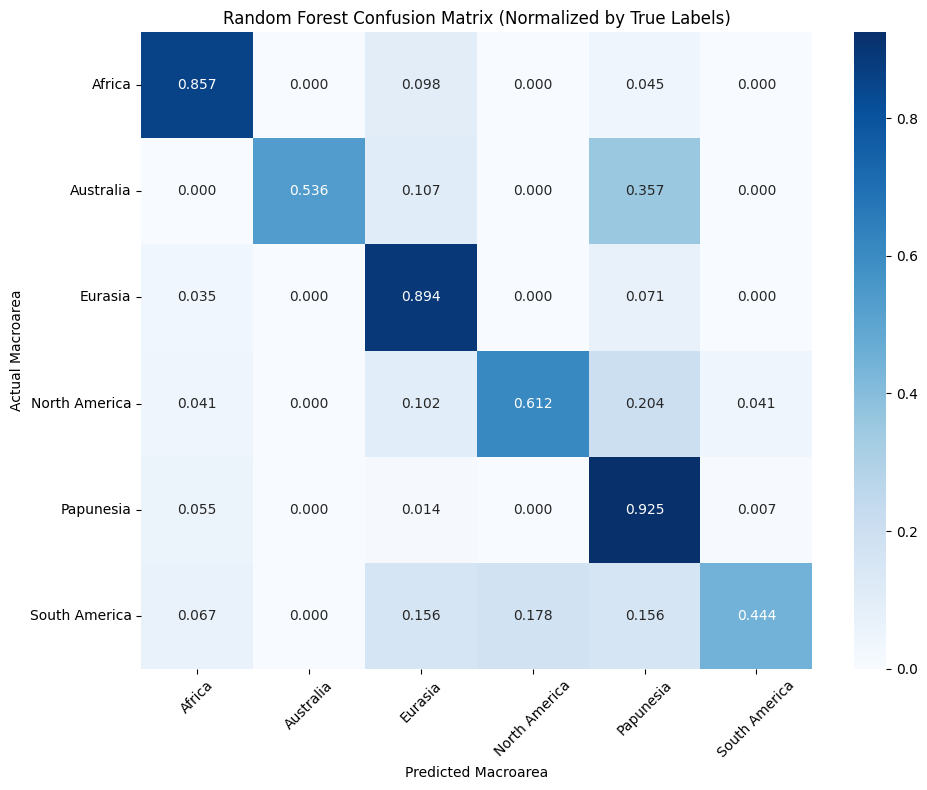


Most Confusable Pairs of Macroareas:
(Looking for high off-diagonal values in confusion matrix)

Top confusable pairs (actual → predicted, confusion rate):
 1. Australia → Papunesia: 0.357 (35.7%)
 2. North America → Papunesia: 0.204 (20.4%)
 3. South America → North America: 0.178 (17.8%)
 4. South America → Eurasia: 0.156 (15.6%)
 5. South America → Papunesia: 0.156 (15.6%)
 6. Australia → Eurasia: 0.107 (10.7%)
 7. North America → Eurasia: 0.102 (10.2%)

Most problematic macroarea pairs:
Bidirectional confusion (hardest pairs to distinguish):
1. Australia ↔ Papunesia: 0.357 average confusion
2. North America ↔ Papunesia: 0.204 average confusion
3. North America ↔ South America: 0.178 average confusion
4. Eurasia ↔ South America: 0.156 average confusion
5. Papunesia ↔ South America: 0.156 average confusion

Random Forest Feature Importance (Top 5):
1. GB044_absent: 0.013585
2. GB117_present: 0.009873
3. GB044_present: 0.009671
4. GB117_absent: 0.008650
5. GB042_present: 0.007663

Ta

In [ ]:
# Task 3c: Create and visualize confusion matrix
print("=== Task 3c: Confusion Matrix Analysis ===")

# Create confusion matrix normalized by true labels (rows)
cm_rf = confusion_matrix(y_test, y_pred_rf, normalize='true')

print(f"Confusion Matrix (Random Forest) - Normalized by True Labels:")
print("Values represent: predicted_class_probability | actual_class")
print("\nPredicted class:")
print("      ", end="")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name[:8]:>8}", end="")
print()

print("Actual:")
for i, (class_name, row) in enumerate(zip(label_encoder.classes_, cm_rf)):
    print(f"{class_name[:8]:>8} ", end="")
    for val in row:
        print(f"{val:8.3f}", end="")
    print()

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Random Forest Confusion Matrix (Normalized by True Labels)')
plt.xlabel('Predicted Macroarea')
plt.ylabel('Actual Macroarea')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find the most confusable pairs
print(f"\nMost Confusable Pairs of Macroareas:")
print("(Looking for high off-diagonal values in confusion matrix)")

# Get off-diagonal elements (excluding diagonal)
confusion_pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j:  # Off-diagonal elements
            confusion_rate = cm_rf[i, j]
            if confusion_rate > 0.1:  # Threshold for significant confusion
                actual_class = label_encoder.classes_[i]
                predicted_class = label_encoder.classes_[j]
                confusion_pairs.append((actual_class, predicted_class, confusion_rate))

# Sort by confusion rate
confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop confusable pairs (actual → predicted, confusion rate):")
for i, (actual, predicted, rate) in enumerate(confusion_pairs[:10]):
    print(f"{i+1:2}. {actual} → {predicted}: {rate:.3f} ({rate*100:.1f}%)")

# Identify most problematic pairs
print(f"\nMost problematic macroarea pairs:")
bidirectional_confusion = {}
for actual, predicted, rate in confusion_pairs:
    pair = tuple(sorted([actual, predicted]))
    if pair not in bidirectional_confusion:
        bidirectional_confusion[pair] = []
    bidirectional_confusion[pair].append(rate)

# Calculate average bidirectional confusion
avg_confusion = [(pair, np.mean(rates)) for pair, rates in bidirectional_confusion.items()]
avg_confusion.sort(key=lambda x: x[1], reverse=True)

print("Bidirectional confusion (hardest pairs to distinguish):")
for i, (pair, avg_rate) in enumerate(avg_confusion[:5]):
    print(f"{i+1}. {pair[0]} ↔ {pair[1]}: {avg_rate:.3f} average confusion")

# Feature importance analysis for Random Forest
print(f"\nRandom Forest Feature Importance (Top 5):")
rf_feature_importance = rf_classifier.feature_importances_
top_rf_indices = np.argsort(rf_feature_importance)[::-1][:5]

for i, idx in enumerate(top_rf_indices):
    feature_name = features_binarized.columns[idx]
    importance = rf_feature_importance[idx]
    print(f"{i+1}. {feature_name}: {importance:.6f}")

print("\nTask 3 completed!")
print("Ready to proceed to Task 4 (Support Vector Machine)")

In [ ]:
# Task 4: Support Vector Machine

# Task 4a: Fit a linear Support Vector Machine
print("=== Task 4a: Linear Support Vector Machine ===")

# Create and fit linear SVM with recommended setting for the fudge factor (C parameter)
# The recommended setting is typically C=1.0 (default)
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)

# Make predictions on test data
y_pred_svm_linear = svm_linear.predict(X_test)

# Compute accuracy
zero_one_error_svm_linear = zero_one_loss(y_test, y_pred_svm_linear)
accuracy_svm_linear = 1 - zero_one_error_svm_linear

print("Linear SVM fitted successfully!")
print(f"Kernel: {svm_linear.kernel}")
print(f"C parameter (fudge factor): {svm_linear.C}")
print(f"Accuracy: {accuracy_svm_linear:.4f} ({accuracy_svm_linear*100:.2f}%)")

# Compare with previous approaches
print(f"\nPerformance Comparison:")
try:
    print(f"Decision Tree accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
    dt_comparison = accuracy_svm_linear - accuracy_dt
    print(f"Linear SVM vs Decision Tree: {dt_comparison:+.4f} ({dt_comparison*100:+.2f} pp)")
except NameError:
    print("Decision Tree results not available")

try:
    print(f"Random Forest accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
    rf_comparison = accuracy_svm_linear - accuracy_rf
    print(f"Linear SVM vs Random Forest: {rf_comparison:+.4f} ({rf_comparison*100:+.2f} pp)")
except NameError:
    print("Random Forest results not available")

print("\n" + "="*50 + "\n")



=== Task 4a: Linear Support Vector Machine ===
Linear SVM fitted successfully!
Kernel: linear
C parameter (fudge factor): 1.0
Accuracy: 0.8600 (86.00%)

Performance Comparison:
Decision Tree accuracy:  0.6268 (62.68%)
Linear SVM vs Decision Tree: +0.2333 (+23.33 pp)
Random Forest accuracy:  0.8053 (80.53%)
Linear SVM vs Random Forest: +0.0548 (+5.48 pp)




In [ ]:
# Task 4b: Try RBF kernel
print("=== Task 4b: RBF Kernel Support Vector Machine ===")

# Create and fit SVM with RBF kernel (default kernel)
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train, y_train)

# Make predictions on test data
y_pred_svm_rbf = svm_rbf.predict(X_test)

# Compute accuracy
zero_one_error_svm_rbf = zero_one_loss(y_test, y_pred_svm_rbf)
accuracy_svm_rbf = 1 - zero_one_error_svm_rbf

print("RBF SVM fitted successfully!")
print(f"Kernel: {svm_rbf.kernel}")
print(f"C parameter: {svm_rbf.C}")
print(f"Gamma parameter: {svm_rbf.gamma}")
print(f"Accuracy: {accuracy_svm_rbf:.4f} ({accuracy_svm_rbf*100:.2f}%)")

# Compare RBF with Linear SVM
improvement_rbf = accuracy_svm_rbf - accuracy_svm_linear
print(f"\nRBF vs Linear SVM:")
print(f"Linear SVM accuracy: {accuracy_svm_linear:.4f} ({accuracy_svm_linear*100:.2f}%)")
print(f"RBF SVM accuracy:    {accuracy_svm_rbf:.4f} ({accuracy_svm_rbf*100:.2f}%)")
print(f"Improvement:         {improvement_rbf:+.4f} ({improvement_rbf*100:+.2f} pp)")

if improvement_rbf > 0.01:
    print("✓ RBF kernel shows significant improvement!")
elif improvement_rbf > 0:
    print("~ RBF kernel shows slight improvement")
else:
    print("✗ RBF kernel shows no improvement or performs worse")

print(f"\nComplete Performance Summary:")
print("Method               | Accuracy | Rank")
print("-" * 40)
methods = []
try:
    methods.append(("Decision Tree", accuracy_dt))
except NameError:
    pass
try:
    methods.append(("Random Forest", accuracy_rf))
except NameError:
    pass
methods.append(("Linear SVM", accuracy_svm_linear))
methods.append(("RBF SVM", accuracy_svm_rbf))

# Sort by accuracy
methods.sort(key=lambda x: x[1], reverse=True)
for i, (method, acc) in enumerate(methods):
    print(f"{method:18} | {acc:.4f}   | {i+1}")

print("\n" + "="*50 + "\n")



=== Task 4b: RBF Kernel Support Vector Machine ===
RBF SVM fitted successfully!
Kernel: rbf
C parameter: 1.0
Gamma parameter: scale
Accuracy: 0.8783 (87.83%)

RBF vs Linear SVM:
Linear SVM accuracy: 0.8600 (86.00%)
RBF SVM accuracy:    0.8783 (87.83%)
Improvement:         +0.0183 (+1.83 pp)
✓ RBF kernel shows significant improvement!

Complete Performance Summary:
Method               | Accuracy | Rank
----------------------------------------
RBF SVM            | 0.8783   | 1
Linear SVM         | 0.8600   | 2
Random Forest      | 0.8053   | 3
Decision Tree      | 0.6268   | 4




=== Task 4c: RBF SVM Confusion Matrix Analysis ===
Confusion Matrix (RBF SVM) - Normalized by True Labels:
Values represent: predicted_class_probability | actual_class

Predicted class:
        AfricaAustrali EurasiaNorth AmPapunesiSouth Am
Actual:
  Africa    0.884   0.000   0.089   0.000   0.018   0.009
Australi    0.000   0.857   0.000   0.000   0.143   0.000
 Eurasia    0.027   0.000   0.903   0.000   0.071   0.000
North Am    0.000   0.000   0.102   0.694   0.122   0.082
Papunesi    0.041   0.000   0.014   0.000   0.945   0.000
South Am    0.022   0.000   0.022   0.111   0.044   0.800


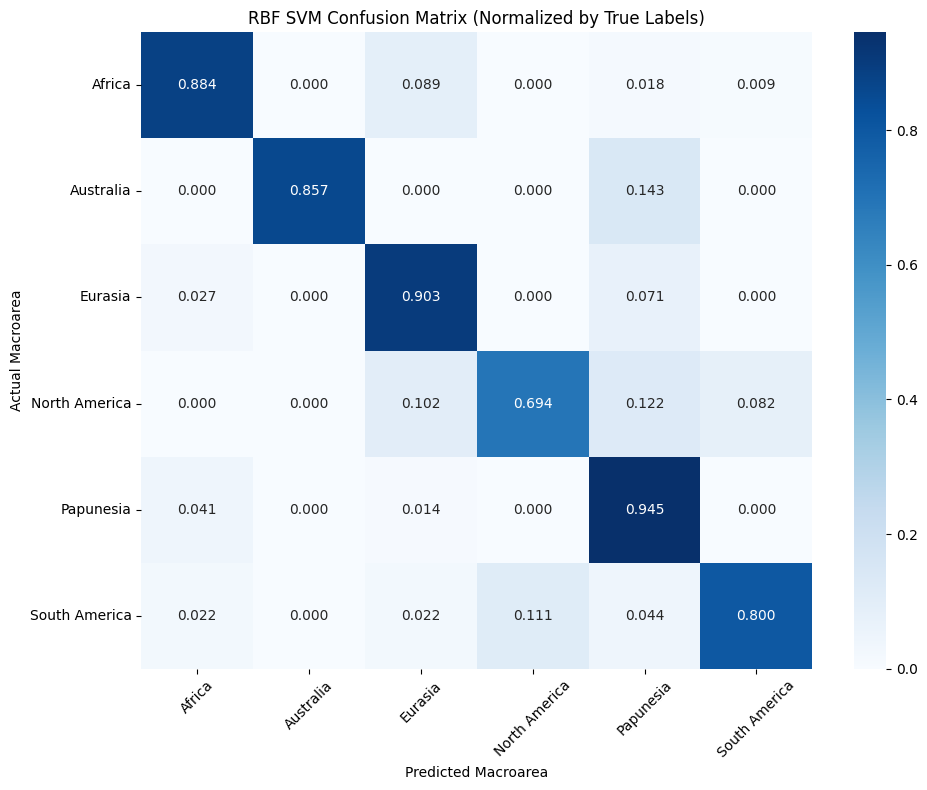


Most Confusable Pairs (RBF SVM):

Top confusable pairs (actual → predicted, confusion rate):
 1. Australia → Papunesia: 0.143 (14.3%)
 2. North America → Papunesia: 0.122 (12.2%)
 3. South America → North America: 0.111 (11.1%)
 4. North America → Eurasia: 0.102 (10.2%)

Comparison with Random Forest Confusion Patterns:
Common confusable pairs between RF and SVM: 3
  - South America → North America
  - North America → Papunesia
  - Australia → Papunesia
✓ Both models struggle with similar macroarea pairs

Ideas for Performance Improvement:
1. Feature engineering: Create combination features
2. Feature selection: Remove irrelevant features
3. Hyperparameter tuning: Optimize C and gamma for RBF
4. Class balancing: Handle imbalanced macroareas
5. Ensemble methods: Combine multiple SVM models
6. Focus on most confusable pairs: Create specialized binary classifiers

Task 4 completed!
Ready to proceed to Task 5 (k-Nearest Neighbors)


In [ ]:
# Task 4c: Confusion matrix for RBF SVM
print("=== Task 4c: RBF SVM Confusion Matrix Analysis ===")

# Create truth-normalized confusion matrix for RBF SVM
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf, normalize='true')

print(f"Confusion Matrix (RBF SVM) - Normalized by True Labels:")
print("Values represent: predicted_class_probability | actual_class")
print("\nPredicted class:")
print("      ", end="")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name[:8]:>8}", end="")
print()

print("Actual:")
for i, (class_name, row) in enumerate(zip(label_encoder.classes_, cm_svm_rbf)):
    print(f"{class_name[:8]:>8} ", end="")
    for val in row:
        print(f"{val:8.3f}", end="")
    print()

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm_rbf, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('RBF SVM Confusion Matrix (Normalized by True Labels)')
plt.xlabel('Predicted Macroarea')
plt.ylabel('Actual Macroarea')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find most confusable pairs for RBF SVM
print(f"\nMost Confusable Pairs (RBF SVM):")
svm_confusion_pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j:  # Off-diagonal elements
            confusion_rate = cm_svm_rbf[i, j]
            if confusion_rate > 0.1:  # Threshold for significant confusion
                actual_class = label_encoder.classes_[i]
                predicted_class = label_encoder.classes_[j]
                svm_confusion_pairs.append((actual_class, predicted_class, confusion_rate))

# Sort by confusion rate
svm_confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop confusable pairs (actual → predicted, confusion rate):")
for i, (actual, predicted, rate) in enumerate(svm_confusion_pairs[:10]):
    print(f"{i+1:2}. {actual} → {predicted}: {rate:.3f} ({rate*100:.1f}%)")

# Compare with Random Forest confusion patterns
print(f"\nComparison with Random Forest Confusion Patterns:")
try:
    # Compare the most confusable pairs
    rf_top_pairs = set()
    for actual, predicted, rate in confusion_pairs[:5]:  # Top 5 from RF
        rf_top_pairs.add((actual, predicted))
    
    svm_top_pairs = set()
    for actual, predicted, rate in svm_confusion_pairs[:5]:  # Top 5 from SVM
        svm_top_pairs.add((actual, predicted))
    
    common_pairs = rf_top_pairs.intersection(svm_top_pairs)
    
    print(f"Common confusable pairs between RF and SVM: {len(common_pairs)}")
    for pair in common_pairs:
        print(f"  - {pair[0]} → {pair[1]}")
        
    if len(common_pairs) > 0:
        print("✓ Both models struggle with similar macroarea pairs")
    else:
        print("✗ Models show different confusion patterns")
        
except NameError:
    print("Random Forest results not available for comparison")

# Ideas for improvement
print(f"\nIdeas for Performance Improvement:")
print("1. Feature engineering: Create combination features")
print("2. Feature selection: Remove irrelevant features")
print("3. Hyperparameter tuning: Optimize C and gamma for RBF")
print("4. Class balancing: Handle imbalanced macroareas")
print("5. Ensemble methods: Combine multiple SVM models")
print("6. Focus on most confusable pairs: Create specialized binary classifiers")

print("\nTask 4 completed!")
print("Ready to proceed to Task 5 (k-Nearest Neighbors)")

In [ ]:
# Task 5: k-Nearest Neighbors Clustering

# Task 5a: Fit k-neighbors classifier and identify default metric
print("=== Task 5a: k-Nearest Neighbors Classifier ===")

# Create and fit k-neighbors classifier with default settings
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)

# Make predictions on test data
y_pred_knn = knn_classifier.predict(X_test)

print("k-Nearest Neighbors classifier fitted successfully!")
print(f"Number of neighbors (k): {knn_classifier.n_neighbors}")
print(f"Default metric: {knn_classifier.metric}")
print(f"Algorithm: {knn_classifier.algorithm}")
print(f"Weights: {knn_classifier.weights}")

# Explain the default metric
print(f"\nDefault Metric Explanation:")
print(f"- Default metric: '{knn_classifier.metric}' (Minkowski distance)")
print(f"- Minkowski parameter (p): {knn_classifier.p}")
print(f"- When p=2 (default), Minkowski distance = Euclidean distance")
print(f"- When p=1, Minkowski distance = Manhattan distance")

print(f"\nDifference from Euclidean distance:")
if knn_classifier.metric == 'minkowski' and knn_classifier.p == 2:
    print("- Actually IS Euclidean distance (Minkowski with p=2)")
    print("- Euclidean: sqrt(sum((x_i - y_i)^2))")
    print("- Good for continuous features and preserves geometric relationships")
elif knn_classifier.metric == 'minkowski' and knn_classifier.p == 1:
    print("- This is Manhattan distance (Minkowski with p=1)")
    print("- Manhattan: sum(|x_i - y_i|)")
    print("- Less sensitive to outliers than Euclidean")
else:
    print(f"- Different metric: {knn_classifier.metric}")

print("\n" + "="*50 + "\n")


=== Task 5a: k-Nearest Neighbors Classifier ===
k-Nearest Neighbors classifier fitted successfully!
Number of neighbors (k): 5
Default metric: minkowski
Algorithm: auto
Weights: uniform

Default Metric Explanation:
- Default metric: 'minkowski' (Minkowski distance)
- Minkowski parameter (p): 2
- When p=2 (default), Minkowski distance = Euclidean distance
- When p=1, Minkowski distance = Manhattan distance

Difference from Euclidean distance:
- Actually IS Euclidean distance (Minkowski with p=2)
- Euclidean: sqrt(sum((x_i - y_i)^2))
- Good for continuous features and preserves geometric relationships




In [ ]:

# Task 5b: Compute accuracy and compare with previous models
print("=== Task 5b: Computing Accuracy ===")

# Compute k-NN accuracy
zero_one_error_knn = zero_one_loss(y_test, y_pred_knn)
accuracy_knn = 1 - zero_one_error_knn

print(f"k-Nearest Neighbors Results:")
print(f"Zero-one loss (error rate): {zero_one_error_knn:.4f}")
print(f"Accuracy: {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)")

# Compare with previous models
print(f"\nPerformance Comparison:")
methods_comparison = []
try:
    print(f"Decision Tree accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
    methods_comparison.append(("Decision Tree", accuracy_dt))
except NameError:
    pass

try:
    print(f"Random Forest accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
    methods_comparison.append(("Random Forest", accuracy_rf))
except NameError:
    pass

try:
    print(f"Linear SVM accuracy:     {accuracy_svm_linear:.4f} ({accuracy_svm_linear*100:.2f}%)")
    methods_comparison.append(("Linear SVM", accuracy_svm_linear))
except NameError:
    pass

try:
    print(f"RBF SVM accuracy:        {accuracy_svm_rbf:.4f} ({accuracy_svm_rbf*100:.2f}%)")
    methods_comparison.append(("RBF SVM", accuracy_svm_rbf))
except NameError:
    pass

methods_comparison.append(("k-NN (k=5)", accuracy_knn))
print(f"k-NN (k=5) accuracy:     {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)")

# Expectation analysis
print(f"\nExpectation Analysis:")
print(f"Would you expect this performance?")
print(f"- k-NN is a lazy learning algorithm (no explicit training)")
print(f"- Performance depends heavily on local neighborhood structure")
print(f"- With binary features, distance might not capture linguistic similarity well")
print(f"- High-dimensional sparse data can suffer from 'curse of dimensionality'")

if accuracy_knn > 0.7:
    print("✓ Better than expected - linguistic features show local structure")
elif accuracy_knn > 0.5:
    print("~ As expected - moderate performance for this type of data")
else:
    print("✗ Worse than expected - high dimensionality might be hurting performance")

print("\n" + "="*50 + "\n")



=== Task 5b: Computing Accuracy ===
k-Nearest Neighbors Results:
Zero-one loss (error rate): 0.1602
Accuracy: 0.8398 (83.98%)

Performance Comparison:
Decision Tree accuracy:  0.6268 (62.68%)
Random Forest accuracy:  0.8053 (80.53%)
Linear SVM accuracy:     0.8600 (86.00%)
RBF SVM accuracy:        0.8783 (87.83%)
k-NN (k=5) accuracy:     0.8398 (83.98%)

Expectation Analysis:
Would you expect this performance?
- k-NN is a lazy learning algorithm (no explicit training)
- Performance depends heavily on local neighborhood structure
- With binary features, distance might not capture linguistic similarity well
- High-dimensional sparse data can suffer from 'curse of dimensionality'
✓ Better than expected - linguistic features show local structure




=== Task 5c: Experimenting with Different k Values ===
Testing different k values:
k    | Accuracy | Performance
-----------------------------------
  1  | 0.8418   | ← BEST
  3  | 0.8398   | = Same
  5  | 0.8398   | = Same
  7  | 0.8215   | ↓ Worse
  9  | 0.8276   | ↓ Worse
 11  | 0.8195   | ↓ Worse
 15  | 0.8154   | ↓ Worse
 20  | 0.8134   | ↓ Worse
 25  | 0.8114   | ↓ Worse
 30  | 0.8114   | ↓ Worse
 50  | 0.7606   | ↓ Worse
100  | 0.7160   | ↓ Worse

Best k value: 1
Best accuracy: 0.8418 (84.18%)


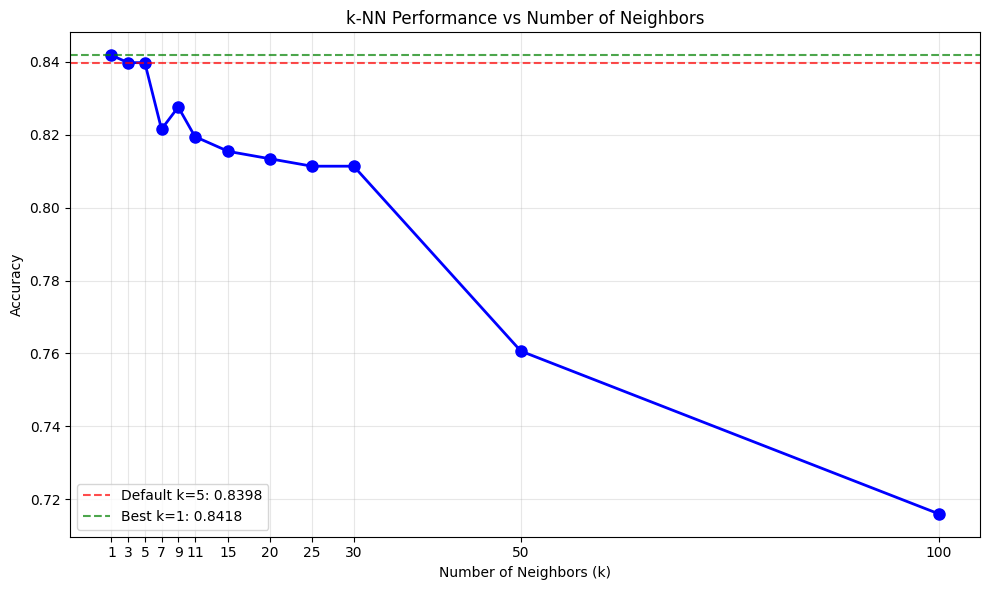


Observations:
- Best k value: 1
- Performance range: 0.7160 to 0.8418
- Improvement from default: +0.0020
- Good k range: 1 to 5
→ Lower k values work better (more local decisions)


In [ ]:
# Task 5c: Experiment with different numbers of neighbors
print("=== Task 5c: Experimenting with Different k Values ===")

# Test different values of k
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30, 50, 100]
k_accuracies = []

print("Testing different k values:")
print("k    | Accuracy | Performance")
print("-" * 35)

for k in k_values:
    # Fit k-NN with different k values
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    
    # Make predictions and compute accuracy
    y_pred_k = knn_k.predict(X_test)
    accuracy_k = 1 - zero_one_loss(y_test, y_pred_k)
    k_accuracies.append(accuracy_k)
    
    # Performance indicator
    if accuracy_k == max(k_accuracies):
        indicator = "← BEST"
    elif accuracy_k > accuracy_knn:
        indicator = "↑ Better"
    elif accuracy_k < accuracy_knn:
        indicator = "↓ Worse"
    else:
        indicator = "= Same"
    
    print(f"{k:3}  | {accuracy_k:.4f}   | {indicator}")

# Find best k
best_k = k_values[np.argmax(k_accuracies)]
best_accuracy = max(k_accuracies)

print(f"\nBest k value: {best_k}")
print(f"Best accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Visualize k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_accuracies, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=accuracy_knn, color='r', linestyle='--', alpha=0.7, label=f'Default k=5: {accuracy_knn:.4f}')
plt.axhline(y=best_accuracy, color='g', linestyle='--', alpha=0.7, label=f'Best k={best_k}: {best_accuracy:.4f}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k-NN Performance vs Number of Neighbors')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Observations
print(f"\nObservations:")
print(f"- Best k value: {best_k}")
print(f"- Performance range: {min(k_accuracies):.4f} to {max(k_accuracies):.4f}")
print(f"- Improvement from default: {best_accuracy - accuracy_knn:+.4f}")

# Identify good range
good_k_values = [k for k, acc in zip(k_values, k_accuracies) if acc >= best_accuracy - 0.005]
print(f"- Good k range: {min(good_k_values)} to {max(good_k_values)}")

# Pattern analysis
if k_values[np.argmax(k_accuracies)] <= 5:
    print("→ Lower k values work better (more local decisions)")
elif k_values[np.argmax(k_accuracies)] >= 20:
    print("→ Higher k values work better (more global decisions)")
else:
    print("→ Moderate k values work best (balanced local/global)")

=== Task 5d: Confusion Matrix for Best k Value ===
Confusion Matrix (k-NN, k=1) - Normalized by True Labels:
Values represent: predicted_class_probability | actual_class

Predicted class:
        AfricaAustrali EurasiaNorth AmPapunesiSouth Am
Actual:
  Africa    0.839   0.000   0.098   0.009   0.027   0.027
Australi    0.036   0.821   0.036   0.000   0.071   0.036
 Eurasia    0.027   0.000   0.929   0.009   0.018   0.018
North Am    0.041   0.000   0.061   0.796   0.041   0.061
Papunesi    0.021   0.000   0.096   0.000   0.842   0.041
South Am    0.044   0.044   0.044   0.111   0.067   0.689


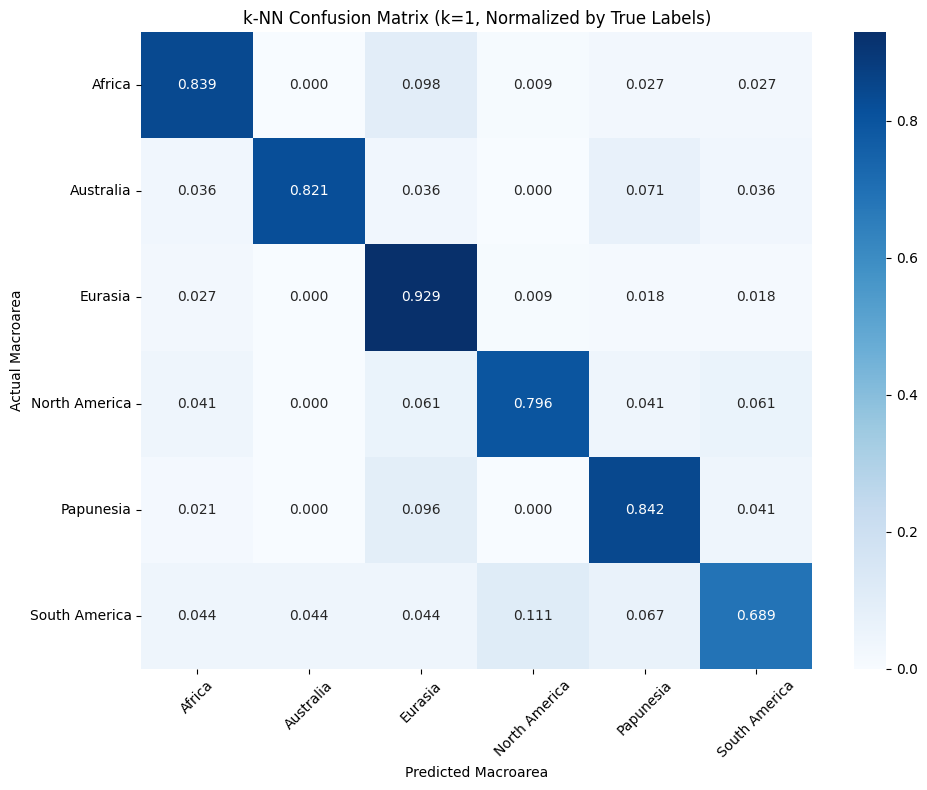

In [ ]:
# Task 5d: Confusion matrix for chosen k value
print("=== Task 5d: Confusion Matrix for Best k Value ===")

# Use the best k value found
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)

# Create truth-normalized confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn_best, normalize='true')

print(f"Confusion Matrix (k-NN, k={best_k}) - Normalized by True Labels:")
print("Values represent: predicted_class_probability | actual_class")
print("\nPredicted class:")
print("      ", end="")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name[:8]:>8}", end="")
print()

print("Actual:")
for i, (class_name, row) in enumerate(zip(label_encoder.classes_, cm_knn)):
    print(f"{class_name[:8]:>8} ", end="")
    for val in row:
        print(f"{val:8.3f}", end="")
    print()

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'k-NN Confusion Matrix (k={best_k}, Normalized by True Labels)')
plt.xlabel('Predicted Macroarea')
plt.ylabel('Actual Macroarea')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [ ]:
# Compare confusion patterns with previous models
print(f"\nDifferences from Previous Confusion Matrices:")

# Find most confusable pairs for k-NN
knn_confusion_pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j:  # Off-diagonal elements
            confusion_rate = cm_knn[i, j]
            if confusion_rate > 0.1:  # Threshold for significant confusion
                actual_class = label_encoder.classes_[i]
                predicted_class = label_encoder.classes_[j]
                knn_confusion_pairs.append((actual_class, predicted_class, confusion_rate))

# Sort by confusion rate
knn_confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop confusable pairs for k-NN:")
for i, (actual, predicted, rate) in enumerate(knn_confusion_pairs[:5]):
    print(f"{i+1:2}. {actual} → {predicted}: {rate:.3f} ({rate*100:.1f}%)")

# Compare with other models
print(f"\nComparison with Other Models:")
print("- k-NN uses local similarity in feature space")
print("- Tree-based methods use hierarchical feature splits")
print("- SVM uses margin-based decision boundaries")
print("- Different algorithms may show different confusion patterns")




Differences from Previous Confusion Matrices:

Top confusable pairs for k-NN:
 1. South America → North America: 0.111 (11.1%)

Comparison with Other Models:
- k-NN uses local similarity in feature space
- Tree-based methods use hierarchical feature splits
- SVM uses margin-based decision boundaries
- Different algorithms may show different confusion patterns


In [ ]:
# Final summary
print("FINAL PERFORMANCE SUMMARY")


final_methods = []
try:
    final_methods.append(("Decision Tree", accuracy_dt))
except NameError:
    pass
try:
    final_methods.append(("Random Forest", accuracy_rf))
except NameError:
    pass
try:
    final_methods.append(("Linear SVM", accuracy_svm_linear))
except NameError:
    pass
try:
    final_methods.append(("RBF SVM", accuracy_svm_rbf))
except NameError:
    pass
final_methods.append((f"k-NN (k={best_k})", best_accuracy))

# Sort by accuracy
final_methods.sort(key=lambda x: x[1], reverse=True)

print("Method               | Accuracy | Rank")
print("-" * 40)
for i, (method, acc) in enumerate(final_methods):
    print(f"{method:18} | {acc:.4f}   | {i+1}")

print(f"\nBest performing method: {final_methods[0][0]} ({final_methods[0][1]:.4f})")

FINAL PERFORMANCE SUMMARY
Method               | Accuracy | Rank
----------------------------------------
RBF SVM            | 0.8783   | 1
Linear SVM         | 0.8600   | 2
k-NN (k=1)         | 0.8418   | 3
Random Forest      | 0.8053   | 4
Decision Tree      | 0.6268   | 5

Best performing method: RBF SVM (0.8783)
